# Football Analyst — Getting Started

This notebook is your **study lab**. The reusable code lives in the `football_analyst/`
package; here you just call it, see the output, and experiment.

Three projects, one per metric family:
1. **Shot map + xG** — chance quality
2. **Pass map** — ball progression & passing
3. **Player radar** — fair player comparison (per 90 minutes)

Data: **StatsBomb Open Data** (free). First run downloads & caches to `sb_cache/`;
after that it's offline and instant.

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # make the package importable from notebooks/
import matplotlib.pyplot as plt
import football_analyst as fa

db = fa.StatsBomb()          # cache-first data gateway
MATCH = 8658                 # 2018 World Cup final: France 4-2 Croatia

## 0. Peek at the raw data

Everything is built on the **events** table: one row per action.

In [2]:
events = db.events(MATCH)
print(events.shape)
events["type"].value_counts().head(10)

(2978, 79)


type
Pass             846
Ball Receipt*    747
Carry            617
Pressure         254
Ball Recovery     88
Duel              53
Clearance         37
Camera On         34
Miscontrol        33
Block             33
Name: count, dtype: int64

## 1. Shot map + xG

**xG** = probability a shot is scored (0-1). Sum it up to see who *created* more,
regardless of finishing luck. Marker size = xG, ★ = goal.

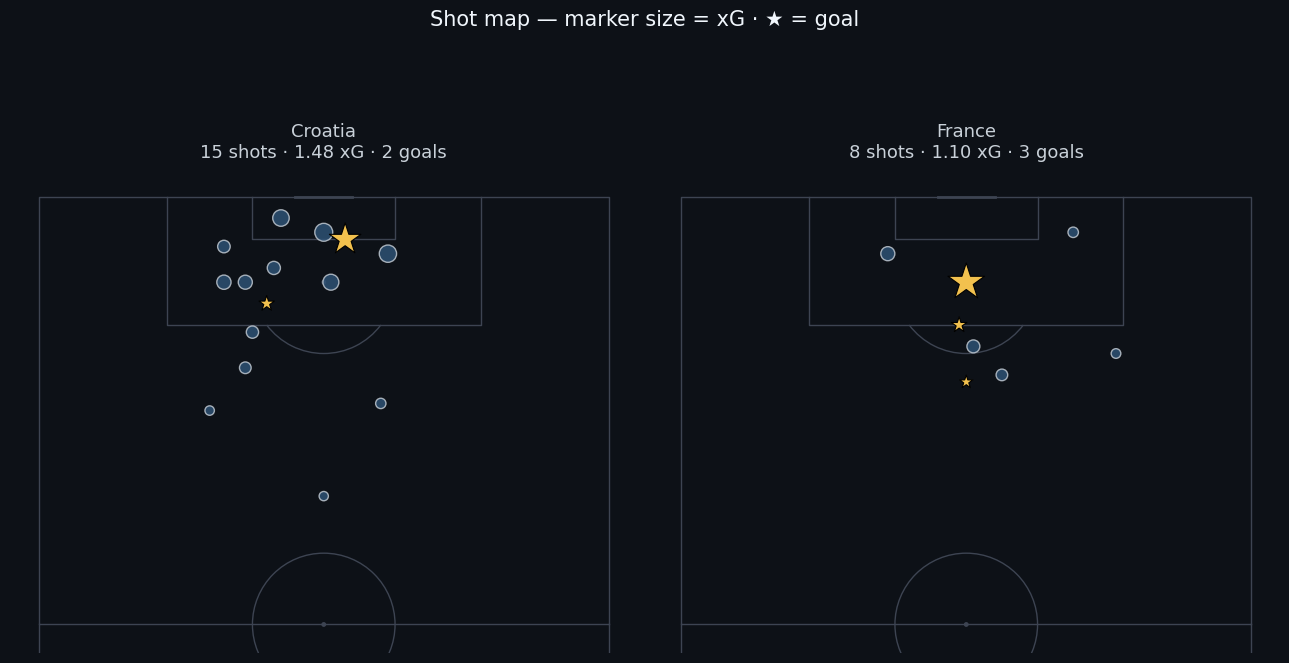

In [3]:
fa.shot_map(MATCH, db=db, show=True);

Want the numbers, not the picture? Every viz has a `get_*` data function:

In [4]:
from football_analyst.viz.shot_map import get_shots
shots = get_shots(MATCH, db)
shots.groupby("team")[["xg"]].sum().round(2)

,xg
team,
Croatia,1.48
France,1.10


## 2. Pass map

Blue = **progressive** (moves ball >=25% closer to goal), grey = completed,
red = incomplete. Try a player, then a whole team.

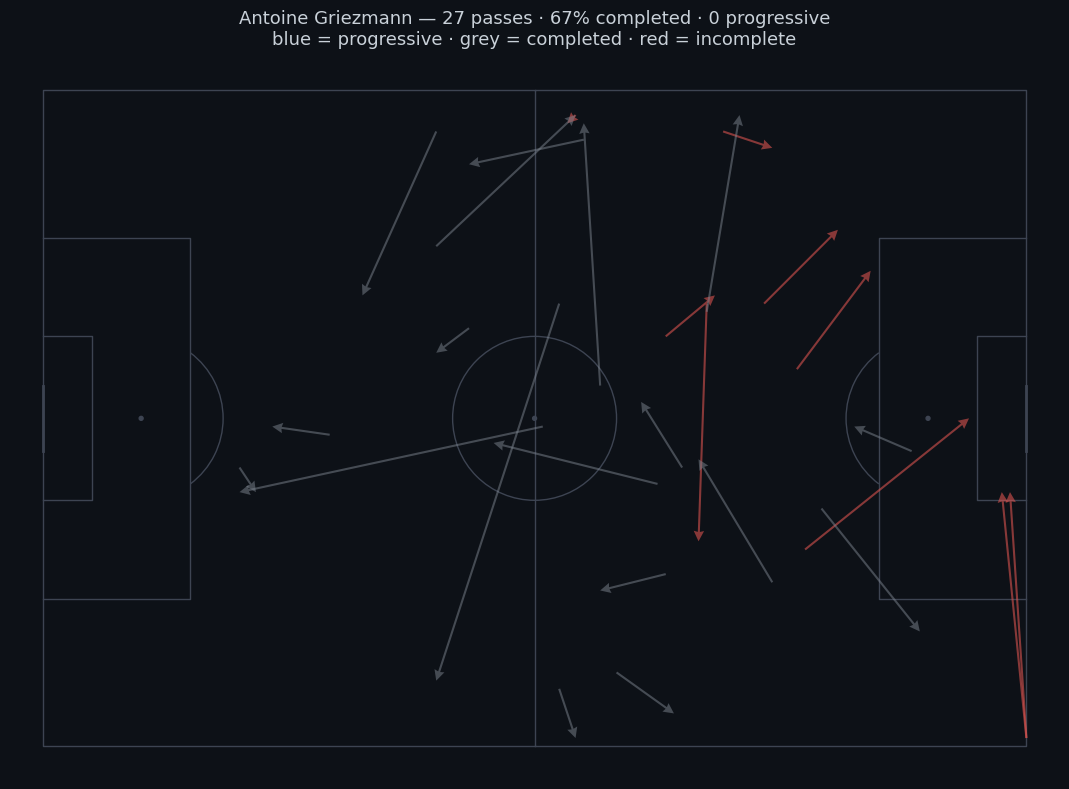

In [5]:
fa.pass_map(MATCH, player="Antoine Griezmann", db=db, show=True);

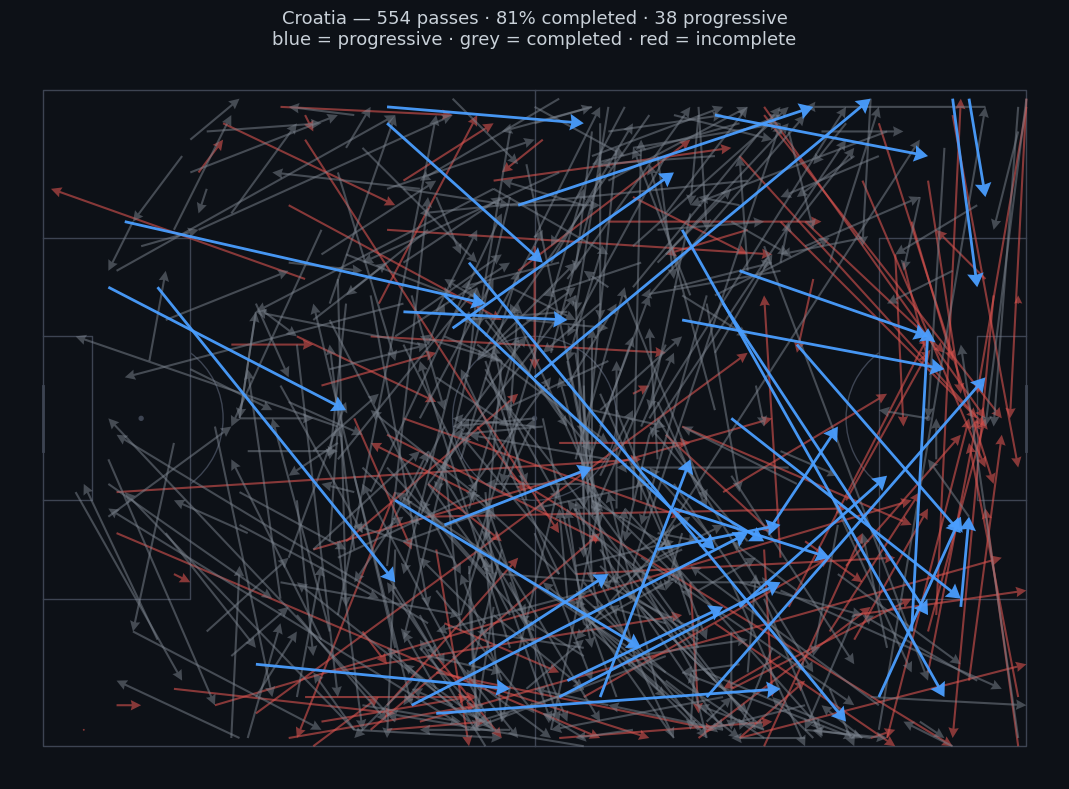

In [6]:
fa.pass_map(MATCH, team="Croatia", db=db, show=True);

## 3. Player comparison radar

Each axis is a **per-90** metric so a starter and a sub compare fairly.
Pass a list of match ids for a more reliable picture.

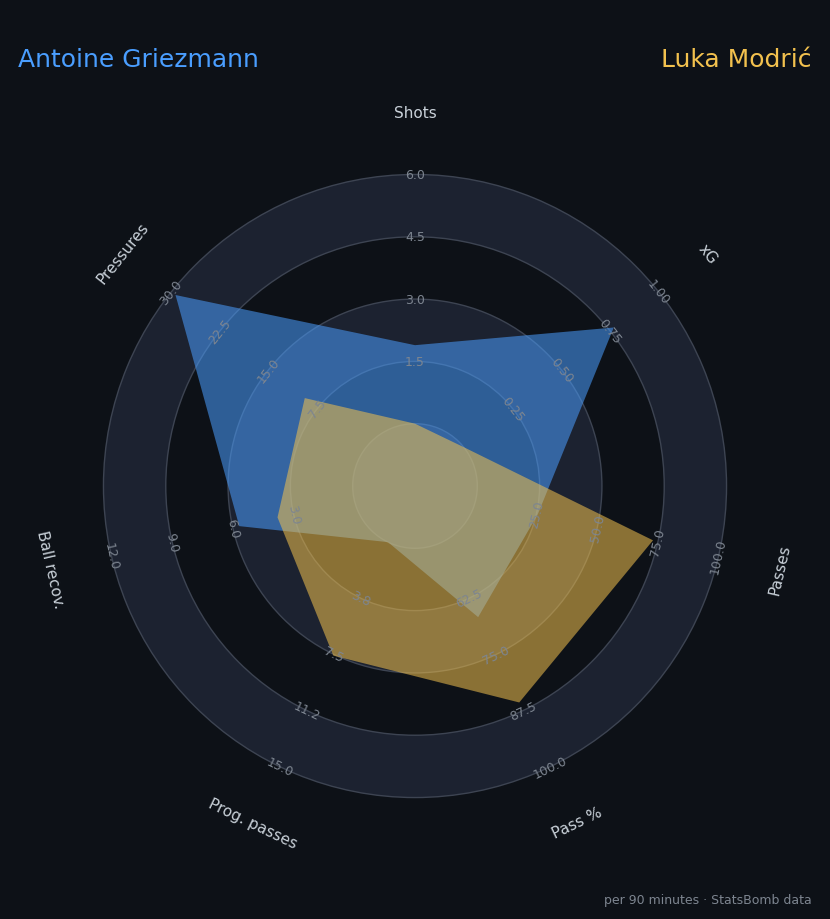

In [7]:
fa.player_radar("Antoine Griezmann", "Luka Modrić", [MATCH], db=db, show=True);

In [8]:
fa.player_season_metrics(MATCH, "Luka Modrić", db)

{'Shots': 0.0,
 'xG': np.float64(0.0),
 'Passes': 72.95,
 'Pass %': 85.7,
 'Prog. passes': 7.58,
 'Ball recov.': 3.79,
 'Pressures': 9.47}

## Your turn — experiment

- Swap in other players (use `events['player'].unique()` to find names).
- Try another match: `db.matches(43, 3)` lists all 2018 World Cup games.
- Change the progressive-pass threshold in `viz/pass_map.py` and re-run.

In [9]:
# scratch cell
sorted(events["player"].dropna().unique())[:20]

['Andrej Kramarić',
 'Ante Rebić',
 'Antoine Griezmann',
 'Benjamin Pavard',
 'Blaise Matuidi',
 'Corentin Tolisso',
 'Danijel Subašić',
 'Dejan Lovren',
 'Domagoj Vida',
 'Hugo Lloris',
 'Ivan Perišić',
 'Ivan Rakitić',
 'Ivan Strinić',
 'Kylian Mbappé Lottin',
 'Lucas Hernández Pi',
 'Luka Modrić',
 'Marcelo Brozović',
 'Mario Mandžukić',
 'Marko Pjaca',
 "N''Golo Kanté"]